# ⚽ Analyzing FIFA Rankings & World Cup Success with Data Visualization

## #Introduction
Every four years, millions of soccer fans try to predict who will lift the FIFA World Cup trophy.

One of the most popular ways to compare teams is the FIFA World Ranking system. Teams are ranked based on their international performances, with stronger teams receiving higher rankings.

But how useful are these rankings? Can FIFA rankings actually predict how teams perform at the World Cup?

In this project, we'll analyze every FIFA World Cup from 1994 to 2022 and investigate whether highly ranked teams consistently finish higher in the tournament. We will do this using these Python libraries:

- pandas
- numpy
- matplotlib
- seaborn
- plotly

We will start by importing these libraries that we will using throughout the project:

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
rankings = pd.read_csv("fifa_mens_rank.csv")
matches = pd.read_csv("matches_1930_2022.csv")

rankings["date"] = pd.to_datetime(rankings["date"])

rankings = rankings[["date", "team", "rank"]]

In [2]:
TARGET_YEARS = [
    1994,
    1998,
    2002,
    2006,
    2010,
    2014,
    2018,
    2022
]

matches = matches[
    matches["Year"].isin(
        TARGET_YEARS
    )
]

print(rankings.shape)
print(matches.shape)

(13130, 3)
(500, 9)


In [3]:
def build_finish_table(matches):

    team_results = []

    for year in TARGET_YEARS:

        wc = matches[
            matches["Year"] == year
        ]

        teams = pd.unique(
            pd.concat([
                wc["home_team"],
                wc["away_team"]
            ])
        )

        for team in teams:

            games = wc[
                (wc["home_team"] == team)
                |
                (wc["away_team"] == team)
            ]

            rounds = games["Round"].unique()

            finish = 32

            if "Final" in rounds:
                finish = 2

            elif "Third-place match" in rounds:
                finish = 4

            elif "Semi-finals" in rounds:
                finish = 4

            elif "Quarter-finals" in rounds:
                finish = 8

            elif "Round of 16" in rounds:
                finish = 16

            team_results.append(
                [year, team, finish]
            )

    return pd.DataFrame(
        team_results,
        columns=[
            "Year",
            "team",
            "Finish"
        ]
    )

team_results = build_finish_table(
    matches
)

team_results.head()

,Year,team,Finish
0,1994,Brazil,2
1,1994,Sweden,4
2,1994,Bulgaria,4
3,1994,Romania,8
4,1994,Italy,2


In [4]:
def get_snapshot(
    rankings,
    matches,
    year
):

    world_cup_start = pd.to_datetime(
        matches[
            matches["Year"] == year
        ]["Date"].min()
    )

    snapshot_date = (
        rankings[
            rankings["date"]
            < world_cup_start
        ]["date"]
        .max()
    )

    return (
        rankings[
            rankings["date"]
            <= snapshot_date
        ]
        .sort_values("date")
        .groupby("team")
        .tail(1)
    )

In [5]:
master_rows = []

for year in TARGET_YEARS:

    snapshot = get_snapshot(
        rankings,
        matches,
        year
    )

    merged = (
        team_results[
            team_results["Year"]
            == year
        ]
        .merge(
            snapshot[
                ["team", "rank"]
            ],
            on="team",
            how="left"
        )
    )

    master_rows.append(
        merged
    )

dataset = pd.concat(
    master_rows,
    ignore_index=True
)

dataset.head()

,Year,team,Finish,rank
0,1994,Brazil,2,5.0
1,1994,Sweden,4,29.0
2,1994,Bulgaria,4,82.0
3,1994,Romania,8,45.0
4,1994,Italy,2,10.0


In [6]:
dataset["Prediction_Error"] = abs(
    dataset["rank"]
    - dataset["Finish"]
)


dataset["Team_Year"] = (
    dataset["team"]
    + " ("
    + dataset["Year"].astype(str)
    + ")"
)

dataset.head()

,Year,team,Finish,rank,Prediction_Error,Team_Year
0,1994,Brazil,2,5.0,3.0,Brazil (1994)
1,1994,Sweden,4,29.0,25.0,Sweden (1994)
2,1994,Bulgaria,4,82.0,78.0,Bulgaria (1994)
3,1994,Romania,8,45.0,37.0,Romania (1994)
4,1994,Italy,2,10.0,8.0,Italy (1994)


In [7]:
print(
    f"Teams analyzed: {len(dataset)}"
)

print(
    f"World Cups analyzed: "
    f"{dataset['Year'].nunique()}"
)

print(
    f"Average prediction error: "
    f"{dataset['Prediction_Error'].mean():.2f}"
)

print(
    f"Overall correlation: "
    f"{dataset['rank'].corr(dataset['Finish']):.3f}"
)

Teams analyzed: 248
World Cups analyzed: 8
Average prediction error: 15.65
Overall correlation: 0.432


In [8]:
fig = px.scatter(
    dataset,
    x="rank",
    y="Finish",
    color="Year",
    hover_name="team",
    hover_data=[
        "Prediction_Error"
    ],
    title="FIFA Ranking vs World Cup Finish"
)

fig.update_yaxes(
    autorange="reversed"
)

fig.show()

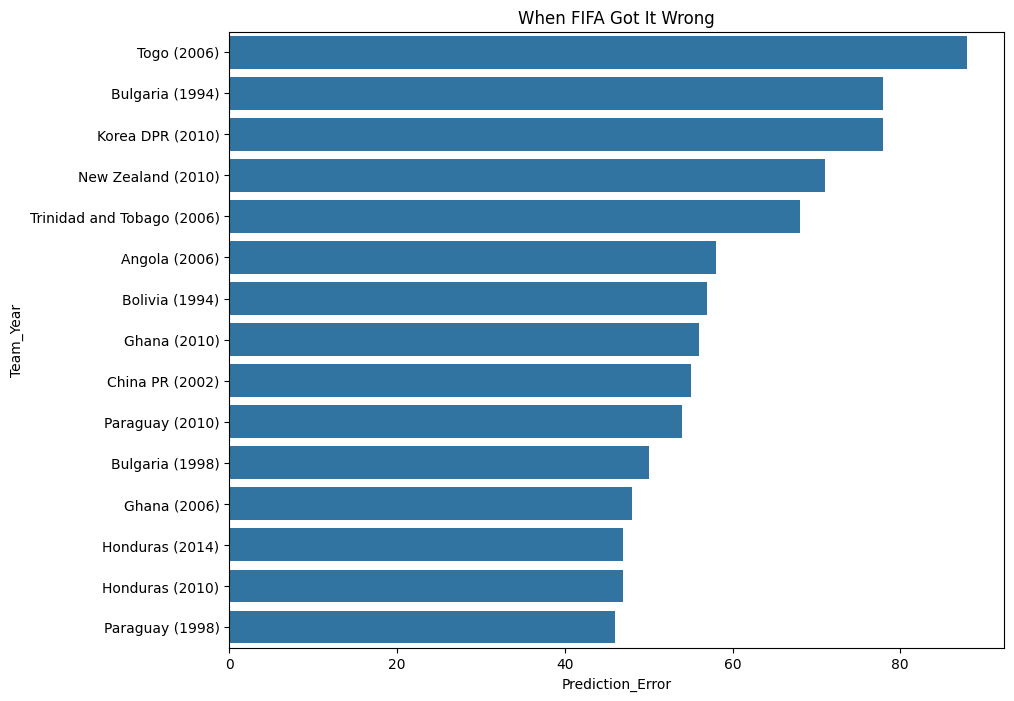

In [9]:
top = (
    dataset
    .sort_values(
        "Prediction_Error",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top,
    x="Prediction_Error",
    y="Team_Year"
)

plt.title(
    "When FIFA Got It Wrong"
)

plt.show()

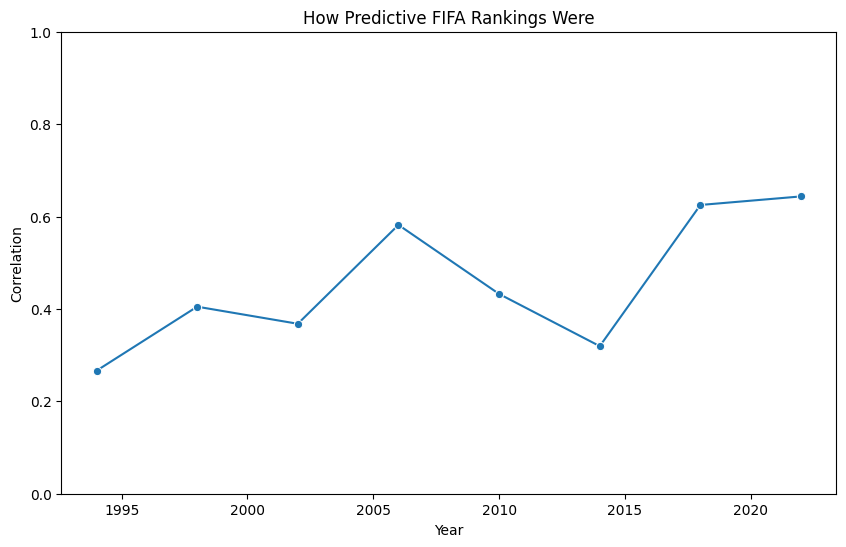

In [10]:
corrs = []

for year in TARGET_YEARS:

    subset = dataset[
        dataset["Year"] == year
    ]

    corr = subset[
        "rank"
    ].corr(
        subset["Finish"]
    )

    corrs.append([
        year,
        corr
    ])

corr_df = pd.DataFrame(
    corrs,
    columns=[
        "Year",
        "Correlation"
    ]
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=corr_df,
    x="Year",
    y="Correlation",
    marker="o"
)

plt.ylim(0,1)

plt.title(
    "How Predictive FIFA Rankings Were"
)

plt.show()

In [11]:
print(
    f"Overall correlation: "
    f"{dataset['rank'].corr(dataset['Finish']):.3f}"
)

print(
    f"Average prediction error: "
    f"{dataset['Prediction_Error'].mean():.2f}"
)

Overall correlation: 0.432
Average prediction error: 15.65
